In [64]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [3]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

In [4]:
train_df = pd.read_csv('data_train_post_n_smoothing.csv', sep="\t")
test_df = pd.read_csv('data_test_post_n_smoothing.csv', sep="\t")

Simple MLP

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df.iloc[:,-2::-1])).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

Device is cuda


In [6]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model

Sequential(
  (0): Linear(in_features=700, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
  (5): Sigmoid()
)

Epoch 00 | Train MSE: 0.060044 | Val MSE: 0.047926
Epoch 10 | Train MSE: 0.020497 | Val MSE: 0.018225
Epoch 20 | Train MSE: 0.013628 | Val MSE: 0.010799
Epoch 30 | Train MSE: 0.012022 | Val MSE: 0.009349
Epoch 40 | Train MSE: 0.009993 | Val MSE: 0.009725
Epoch 50 | Train MSE: 0.009520 | Val MSE: 0.008373
Epoch 60 | Train MSE: 0.009127 | Val MSE: 0.007372
Epoch 70 | Train MSE: 0.009191 | Val MSE: 0.007317
Epoch 80 | Train MSE: 0.009304 | Val MSE: 0.007273
Epoch 90 | Train MSE: 0.009157 | Val MSE: 0.007190


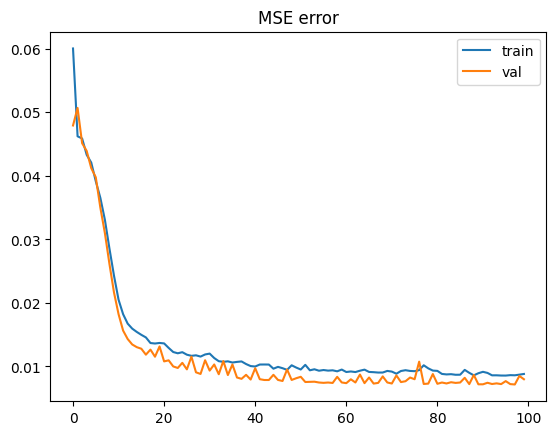

In [7]:
epochs = 100  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.08937692 R²: 0.85032856 MAE: 0.07113052


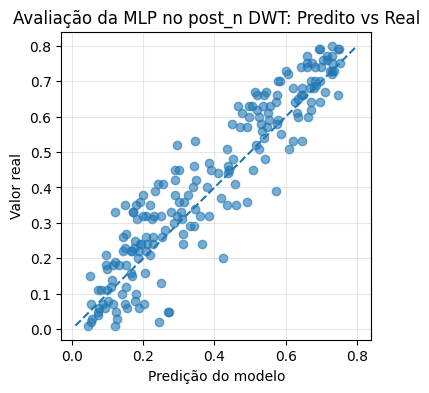

In [8]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(4,4))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title(f"Avaliação da MLP no post_n DWT: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [209]:
write_csv_file(y_pred.squeeze().detach().cpu().numpy())

,CPMG,%
0,CPMG_000.csv,0.386244
1,CPMG_001.csv,0.694590
2,CPMG_002.csv,0.217418
3,CPMG_003.csv,0.326525
4,CPMG_004.csv,0.102075
...,...,...
995,CPMG_995.csv,0.217330
996,CPMG_996.csv,0.735972
997,CPMG_997.csv,0.179982
998,CPMG_998.csv,0.328672


Simple MLP with dropout

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

Device is cuda


In [10]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model

Sequential(
  (0): Linear(in_features=700, out_features=256, bias=True)
  (1): Dropout(p=0.2, inplace=False)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): Dropout(p=0.2, inplace=False)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=1, bias=True)
  (7): Sigmoid()
)

Epoch 00 | Train MSE: 0.056056 | Val MSE: 0.043653
Epoch 10 | Train MSE: 0.016805 | Val MSE: 0.012611
Epoch 20 | Train MSE: 0.012257 | Val MSE: 0.009958
Epoch 30 | Train MSE: 0.010899 | Val MSE: 0.008849
Epoch 40 | Train MSE: 0.010315 | Val MSE: 0.008868
Epoch 50 | Train MSE: 0.011196 | Val MSE: 0.009327
Epoch 60 | Train MSE: 0.009643 | Val MSE: 0.007864
Epoch 70 | Train MSE: 0.009752 | Val MSE: 0.009027
Epoch 80 | Train MSE: 0.009887 | Val MSE: 0.008194
Epoch 90 | Train MSE: 0.009009 | Val MSE: 0.007490


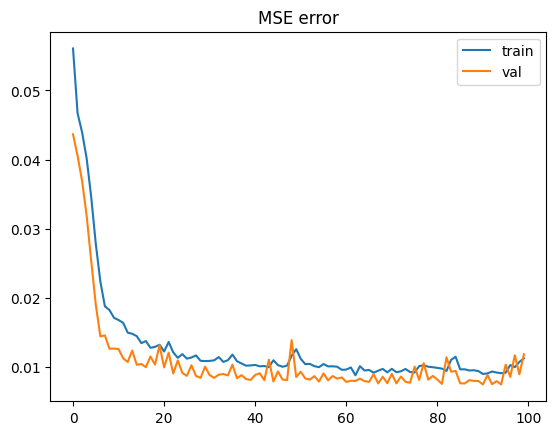

In [11]:
epochs = 100  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.108917624 R²: 0.7581739 MAE: 0.08640684


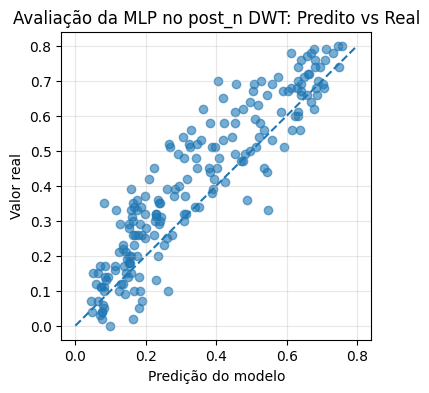

In [12]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(4,4))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title(f"Avaliação da MLP no post_n DWT: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
Xtest = torch.Tensor(np.array(test_df)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

plt.scatter(y_good, ytest_pred)
plt.title('Comparison against good prediction');
write_csv_file(ytest_pred)
print("csv saved");

NameError: name 'y_good' is not defined

### Fazendo PCA

In [120]:
train_df = pd.read_csv('data_train_post_n_smoothing.csv', sep="\t")
test_df = pd.read_csv('data_test_post_n_smoothing.csv', sep="\t")

In [121]:
pca = sklearn.decomposition.PCA(n_components=.999)
pca.fit(train_df.iloc[:,:-1])

,n_components,0.999
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [122]:
train_df_pca = pd.DataFrame(pca.transform(train_df.iloc[:,:-1]))
train_df_pca['y'] = train_df['y']
test_df_pca = pd.DataFrame(pca.transform(test_df))
# train_df_pca.to_csv("data_train_PCA.csv", sep="\t")
# test_df_pca.to_csv("data_test_PCA.csv", sep="\t")
train_df_pca.shape

(1000, 12)

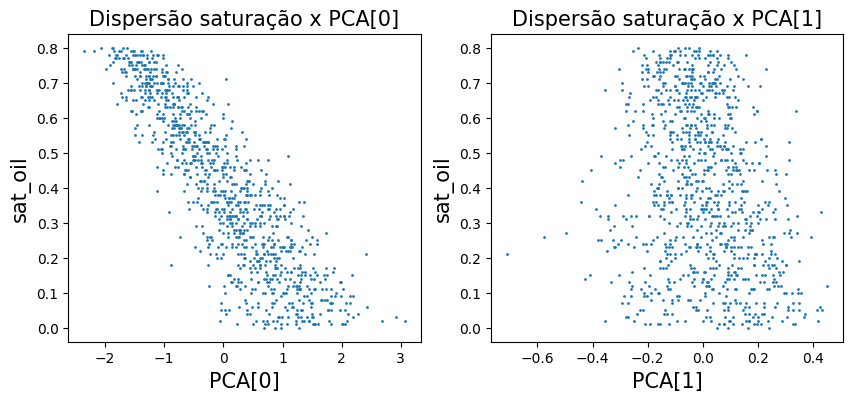

In [125]:
cmap = plt.cm.tab10
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].scatter(train_df_pca.iloc[:,0], train_df_pca['y'], s=1)
ax[0].set_title('Dispersão saturação x PCA[0]', fontsize=15)
ax[0].set_xlabel("PCA[0]", fontsize=15)
ax[0].set_ylabel("sat_oil", fontsize=15)

ax[1].scatter(train_df_pca.iloc[:,1], train_df_pca['y'],s=1)
ax[1].set_title('Dispersão saturação x PCA[1]', fontsize=15)
ax[1].set_xlabel("PCA[1]", fontsize=15)
ax[1].set_ylabel("sat_oil", fontsize=15)
    
plt.show();

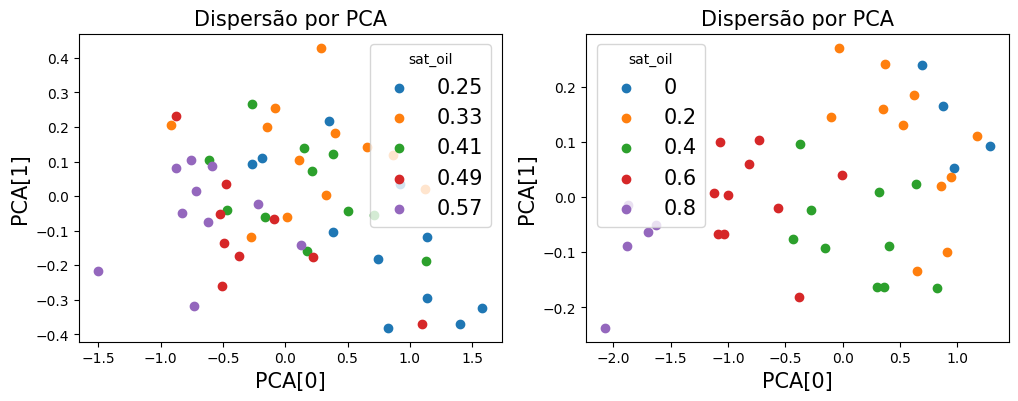

In [126]:
cmap = plt.cm.tab10
fig, ax = plt.subplots(1,2,figsize=(12,4))

for i,sat_oil in enumerate([.25,.33,.41,.49,.57]):
    sel_train_df = train_df_pca[train_df_pca['y']==sat_oil]
    ax[0].scatter(sel_train_df.iloc[0,0], sel_train_df.iloc[0,1], color=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[0].scatter(sel_train_df.iloc[j,0], sel_train_df.iloc[j,1], color=cmap(i%10))
ax[0].legend(fontsize=15, title="sat_oil")
ax[0].set_title('Dispersão por PCA', fontsize=15)
ax[0].set_xlabel("PCA[0]", fontsize=15)
ax[0].set_ylabel("PCA[1]", fontsize=15);

for i,sat_oil in enumerate([0,.2,.4,.6,.8]):
    sel_train_df = train_df_pca[train_df_pca['y']==sat_oil]
    ax[1].scatter(sel_train_df.iloc[0,0], sel_train_df.iloc[0,1], color=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[1].scatter(sel_train_df.iloc[j,0], sel_train_df.iloc[j,1], color=cmap(i%10))
ax[1].legend(fontsize=15, title="sat_oil")
ax[1].set_title('Dispersão por PCA', fontsize=15)
ax[1].set_xlabel("PCA[0]", fontsize=15)
ax[1].set_ylabel("PCA[1]", fontsize=15);

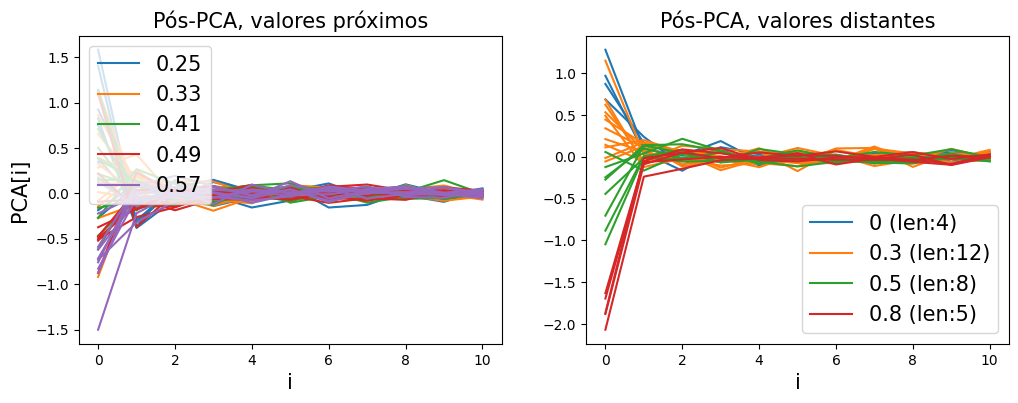

In [127]:
cmap = plt.cm.tab10
fig, ax = plt.subplots(1,2,figsize=(12,4))

for i,sat_oil in enumerate([.25,.33,.41,.49,.57]):
    sel_train_df = train_df_pca[train_df_pca['y']==sat_oil]
    ax[0].plot(range(sel_train_df.shape[1]-1),sel_train_df.iloc[0,:-1], c=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[0].plot(range(sel_train_df.shape[1]-1),sel_train_df.iloc[j,:-1], c=cmap(i%10))
ax[0].legend(fontsize=15)
ax[0].set_title('Pós-PCA, valores próximos', fontsize=15)
ax[0].set_ylabel("PCA[i]", fontsize=15)
ax[0].set_xlabel("i", fontsize=15)

for i,sat_oil in enumerate([0,.3,.5,.8]):
    sel_train_df = train_df_pca[train_df_pca['y']==sat_oil]
    ax[1].plot(range(sel_train_df.shape[1]-1),sel_train_df.iloc[0,:-1], c=cmap(i%10), label=f'{str(sat_oil)} (len:{sel_train_df.shape[0]})')
    for j in range(1,len(sel_train_df)):
        ax[1].plot(range(sel_train_df.shape[1]-1),sel_train_df.iloc[j,:-1], c=cmap(i%10))
ax[1].legend(fontsize=15)
ax[1].set_title('Pós-PCA, valores distantes', fontsize=15)
ax[1].set_xlabel("i", fontsize=15)
    
plt.show();

simple MLP model

In [128]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [129]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    # nn.ReLU(),
    # nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model

Sequential(
  (0): Linear(in_features=11, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
  (5): Sigmoid()
)

Epoch 00 | Train MSE: 0.058323 | Val MSE: 0.037697
Epoch 05 | Train MSE: 0.010167 | Val MSE: 0.011087
Epoch 10 | Train MSE: 0.009270 | Val MSE: 0.009192
Epoch 15 | Train MSE: 0.008407 | Val MSE: 0.008191
Epoch 20 | Train MSE: 0.008060 | Val MSE: 0.007833
Epoch 25 | Train MSE: 0.007886 | Val MSE: 0.007787


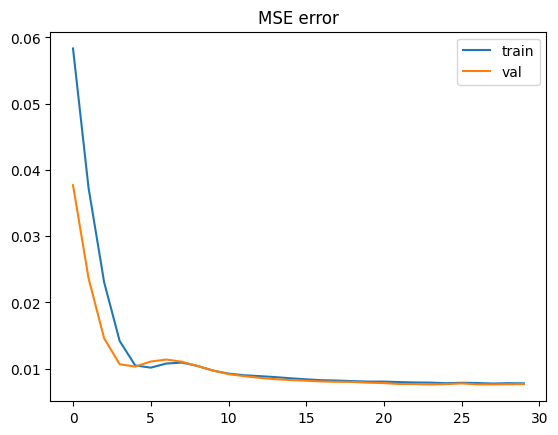

RMSE: 0.087686144 R²: 0.8372933 MAE: 0.07124511


In [130]:
epochs = 30
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

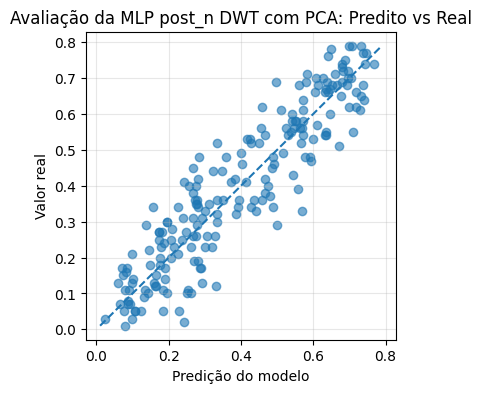

In [131]:
# Gráfico de avaliação
plt.figure(figsize=(4,4))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP post_n DWT com PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

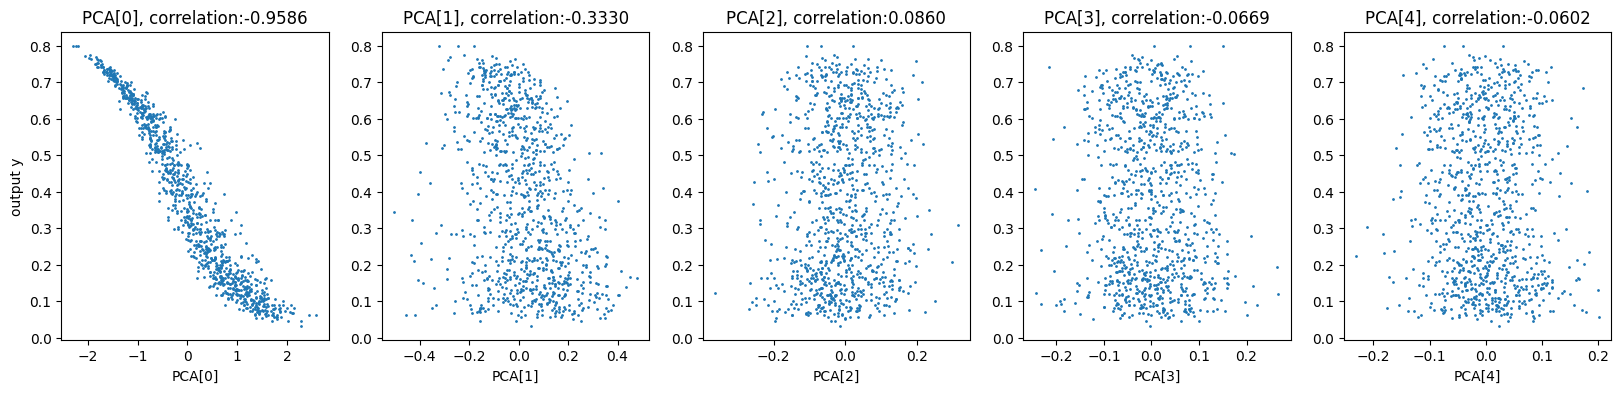

In [140]:
Xtest = torch.Tensor(np.array(test_df_pca)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()
PCA_test = Xtest.squeeze().detach().cpu().numpy()

fig, ax = plt.subplots(1,5, figsize=(20,4))
ax[0].set_ylabel('output y')
for ii,i in enumerate(range(5)):
    ax[ii].scatter(PCA_test[:,i], ytest_pred, s=1)
    ax[ii].set_title(f'PCA[{i}], correlation:{np.corrcoef(PCA_test[:,i], ytest_pred)[0,1]:.4f}')
    ax[ii].set_xlabel(f'PCA[{i}]')
# write_csv_file(ytest_pred)
# print("csv saved");

With Dropout

In [90]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1])).to(device)
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [93]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.Dropout(.2),
    # nn.ReLU(),
    # nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.058920 | Val MSE: 0.044475
Epoch 05 | Train MSE: 0.011554 | Val MSE: 0.014753
Epoch 10 | Train MSE: 0.009637 | Val MSE: 0.010676
Epoch 15 | Train MSE: 0.008729 | Val MSE: 0.009483


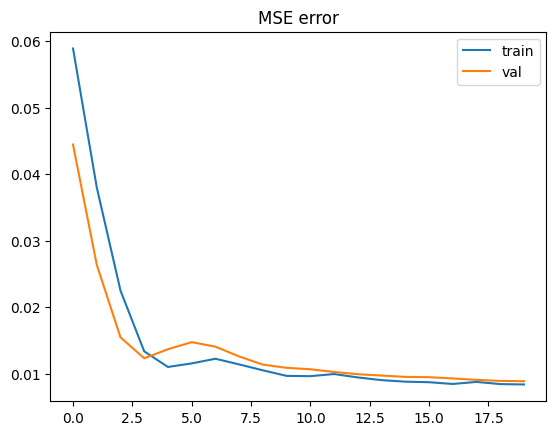

RMSE: 0.09422768 R²: 0.8240136 MAE: 0.07225994


In [94]:
epochs = 20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

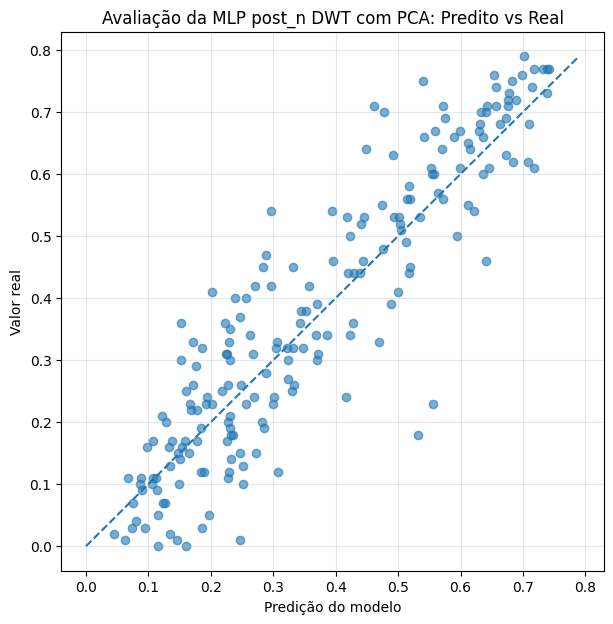

In [95]:
# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP post_n DWT com PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

csv saved


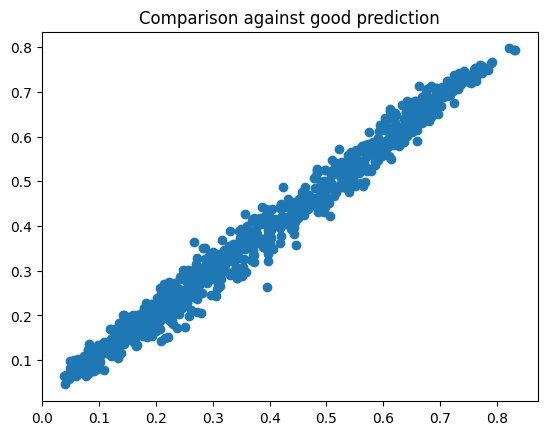

In [96]:
y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

Xtest = torch.Tensor(np.array(test_df_pca)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

plt.scatter(y_good, ytest_pred)
plt.title('Comparison against good prediction');
write_csv_file(ytest_pred)
print("csv saved");

Agora com CatBoost

In [51]:
%pip install catboost

  Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.11.0-py3-none-any.whl.metadata (11 kB)
Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl (99.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.11.0-py3-none-any.whl (423 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


## Catboost: training setup

In [40]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

n_init_points = 500
X = np.array(train_df.iloc[:,:n_init_points])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


RMSE: 0.09839301421004155 R²: 0.8155809803197289 MAE: 0.07921258220582261


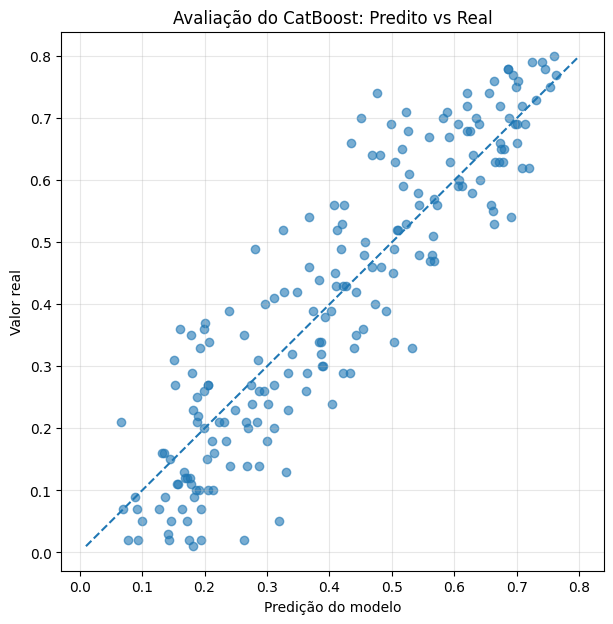

In [41]:
y_pred = model.predict(Xval)

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [196]:
Xtest = np.array(short_test_df.iloc[:,:n_init_points])
write_csv_file(model.predict(Xtest))

,CPMG,%
0,CPMG_000.csv,0.274665
1,CPMG_001.csv,0.669553
2,CPMG_002.csv,0.183837
3,CPMG_003.csv,0.434456
4,CPMG_004.csv,0.072703
...,...,...
995,CPMG_995.csv,0.242696
996,CPMG_996.csv,0.748017
997,CPMG_997.csv,0.209394
998,CPMG_998.csv,0.225531


## Agora uma CNN, por favor

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(1).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [37]:
model = nn.Sequential(
    nn.Conv1d(1,4,5),
    nn.ReLU(),
    nn.AvgPool1d(4),

    nn.Conv1d(4,16,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(16,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),
    
    nn.Flatten(),
    nn.Linear(36,64),
    nn.ReLU(),

    nn.Linear(64,8),
    nn.ReLU(),
        
    nn.Linear(8,1),
    nn.Sigmoid()
).to(device)

#to get the size right in the linear layer
# x = torch.randn(1000, 1, 2201)
# out = model(X)
# print(out.shape)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 04 | Train MSE: 0.052991 | Val MSE: 0.051380
Epoch 09 | Train MSE: 0.052487 | Val MSE: 0.050464
Epoch 14 | Train MSE: 0.050430 | Val MSE: 0.047446
Epoch 19 | Train MSE: 0.043019 | Val MSE: 0.038365
Epoch 24 | Train MSE: 0.021443 | Val MSE: 0.016534
Epoch 29 | Train MSE: 0.011996 | Val MSE: 0.013027
Epoch 34 | Train MSE: 0.013003 | Val MSE: 0.012295
Epoch 39 | Train MSE: 0.011684 | Val MSE: 0.011743
Epoch 44 | Train MSE: 0.011024 | Val MSE: 0.011776
Epoch 49 | Train MSE: 0.010940 | Val MSE: 0.011763
Epoch 54 | Train MSE: 0.010799 | Val MSE: 0.011605
Epoch 59 | Train MSE: 0.010706 | Val MSE: 0.011517
Epoch 64 | Train MSE: 0.010821 | Val MSE: 0.011479
Epoch 69 | Train MSE: 0.011143 | Val MSE: 0.011357
Epoch 74 | Train MSE: 0.010484 | Val MSE: 0.011497
Epoch 79 | Train MSE: 0.010518 | Val MSE: 0.011737
Epoch 84 | Train MSE: 0.010432 | Val MSE: 0.011258
Epoch 89 | Train MSE: 0.010354 | Val MSE: 0.011117
Epoch 94 | Train MSE: 0.010673 | Val MSE: 0.011077
Epoch 99 | Train MSE: 0.010583 

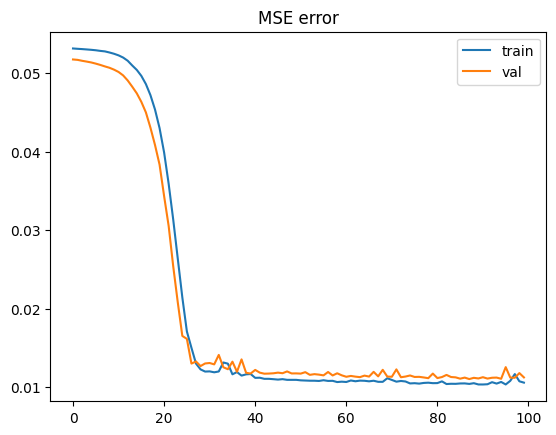

In [38]:
epochs = 100
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch+1)%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.10606897 R²: 0.77820325 MAE: 0.07908359


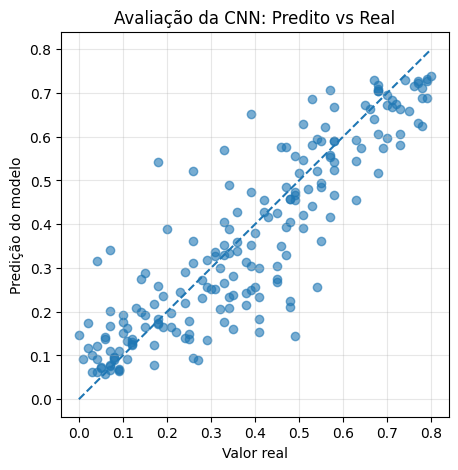

In [39]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()
# print(Xval.shape, yval.shape)

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Valor real")
plt.ylabel("Predição do modelo")
plt.title("Avaliação da CNN: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

## RNN: GRU

In [79]:
train_df = pd.read_csv('data_train_DWT.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT.csv', sep="\t")

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device is {device}")

X = torch.Tensor(np.array(train_df.iloc[:,-2::-1])).unsqueeze(2).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
X.shape

device is cuda


torch.Size([1000, 700, 1])

In [31]:
hidden_size = 16
gru = nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True).to(device)
head = nn.Linear(hidden_size, 1).to(device)

# combine params from both "submodules"
optimizer = torch.optim.Adam(list(gru.parameters()) + list(head.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epoch 01 | train MSE: 0.073883
epoch 02 | train MSE: 0.065794
epoch 03 | train MSE: 0.059438
epoch 04 | train MSE: 0.055295
epoch 05 | train MSE: 0.053112
epoch 06 | train MSE: 0.052504
epoch 07 | train MSE: 0.052680
epoch 08 | train MSE: 0.052846
epoch 09 | train MSE: 0.052759
epoch 10 | train MSE: 0.052627


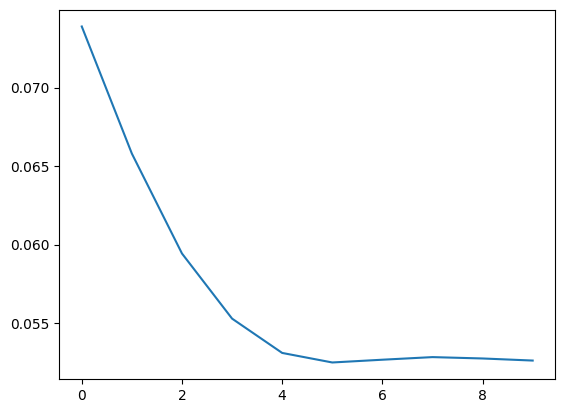

In [32]:
# ----- training loop -----
gru.train(); head.train()
loss_history = []
for epoch in range(10):
    train_loss = 0.0
    for xb, yb in train_loader:
        # forward (manual “forward”)
        out, h = gru(xb)               # out: (B, T, H), h: (1, B, H)
        feat = out[:, -1, :]           # OR: h[-1]  (both are (B, H))
        pred = torch.sigmoid(head(feat))  # keep in [0,1]

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    loss_history.append(train_loss/len(train_loader.dataset))
    print(f"epoch {epoch+1:02d} | train MSE: {train_loss/len(train_loader.dataset):.6f}")
plt.plot(loss_history);

RMSE: 0.23206054 MAE: 0.19946644


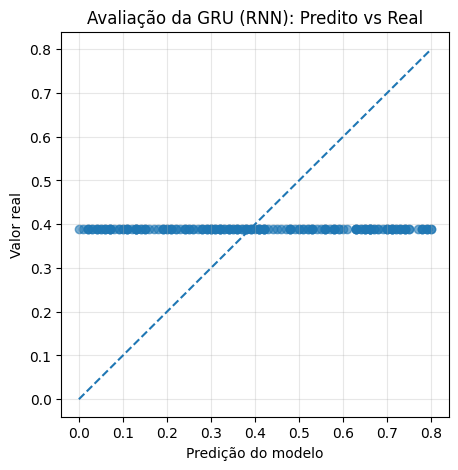

In [33]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

# ----- inference -----
gru.eval(); head.eval()
val_loss = 0
with torch.no_grad():
    for xb, yb in val_loader:
        out, h = gru(xb)
        feat = out[:, -1, :]
        y_pred = torch.sigmoid(head(feat))
        val_loss += criterion(y_pred, yb).item() * xb.size(0)
val_loss /= len(val_loader.dataset)

model.eval()
with torch.no_grad():
    out, h = gru(Xval)
    feat = out[:, -1, :]
    y_pred = torch.sigmoid(head(feat)).squeeze().detach().cpu().numpy()

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred - yval.reshape(-1,1))**2))
mae = np.mean(np.abs((y_pred - yval.reshape(-1,1))))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Horrível, RNN não funciona

## Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:-1])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 700), (1000,), (800, 700), (200, 700), (800,), (200,)]


In [15]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.09185919496707991 R²: 0.8434087867329396 MAE: 0.073049


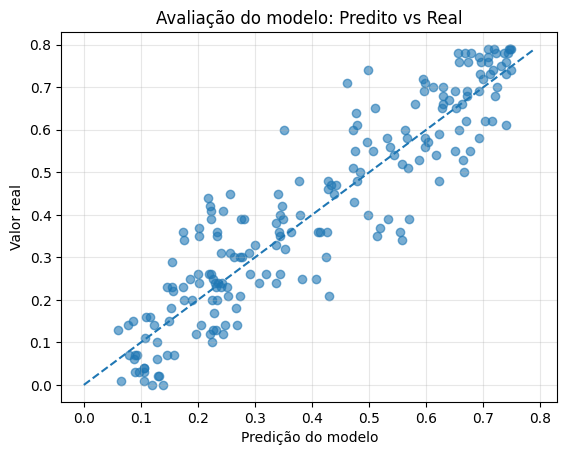

In [16]:
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", np.sqrt(mse), "R²:", 1-mse/np.std(yval)**2,"MAE:", mae)

# Gráfico de avaliação
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

plt.scatter(y_pred, yval, alpha=0.6)
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do modelo: Predito vs Real")
plt.grid(True, alpha=0.3)

plt.show()

,CPMG,%
0,CPMG_000.csv,0.3256
1,CPMG_001.csv,0.7264
2,CPMG_002.csv,0.1834
3,CPMG_003.csv,0.3779
4,CPMG_004.csv,0.1005
...,...,...
995,CPMG_995.csv,0.2994
996,CPMG_996.csv,0.7148
997,CPMG_997.csv,0.1999
998,CPMG_998.csv,0.1709


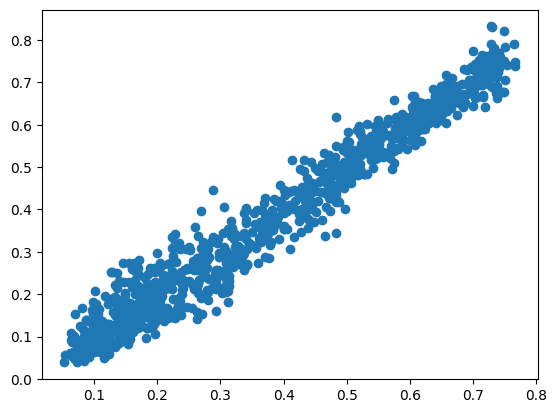

In [25]:
Xtest = np.array(test_df.iloc[:,:])
y_pred_test = model.predict(Xtest)

y_good = pd.read_csv('submissions/time2_trilha1_DWTcurva_PCA.csv', sep='\t').drop('CPMG', axis=1)

plt.scatter(y_pred_test,y_good)
write_csv_file(y_pred_test)

Resultado fraco